In [1]:
import numpy as np
import glob, re, os

def find_folders(root):
    """Map N -> path of its NMentropy_swap.txt file, from subfolders named N<N>."""
    folders = {}
    for path in glob.glob(os.path.join(root, "N*")):
        if not os.path.isdir(path):
            continue
        m = re.fullmatch(r"N(\d+)", os.path.basename(path))
        if not m:
            continue
        N = int(m.group(1))
        fpath = os.path.join(path, "NMentropy_swap.txt")
        if os.path.isfile(fpath):
            folders[N] = fpath
    return dict(sorted(folders.items()))

def load_all(root):
    files = find_folders(root)
    if not files:
        raise FileNotFoundError(f"No N<N>/NMentropy_swap.txt files found under {root}")
    
    N_values = np.array(list(files.keys()))
    g_ref = None
    entropy = None
    error = None
    
    for i, N in enumerate(N_values):
        arr = np.loadtxt(files[N], comments='#')
        arr = arr[arr[:,0].argsort()]
        g, S, err = arr[:,0], arr[:,1], arr[:,2]
        
        if g_ref is None:
            g_ref = g
            entropy = np.full((len(N_values), len(g_ref)), np.nan)
            error   = np.full((len(N_values), len(g_ref)), np.nan)
        else:
            assert np.allclose(g, g_ref), f"g-grid mismatch in N={N}"
        
        entropy[i, :] = S
        error[i, :]   = err
    
    return N_values, g_ref, entropy, error

N_values, g_values, entropy, error = load_all('results/28may2026/')

def f(N, g, tol=1e-6):
    """Return [entropy, error] for given N and g."""
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    j = np.argmin(np.abs(g_values - g))
    assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
    return np.array([entropy[i, j], error[i, j]])

In [2]:
import numpy as np
from numpy.polynomial import Polynomial
from scipy.optimize import curve_fit

# ---------- Fit 1: S(g) at fixed N -> polynomial ----------

def fit_poly_vs_g(N_values, g_values, entropy, error, N, degree=6, auto_reduce=True, verbose=True):
    """
    Weighted polynomial fit of S(g) at fixed N.
    
    If auto_reduce=True: checks the actual numerical rank of the fit and, if the
    requested degree exceeds what the data can support (given g-spacing and weights),
    automatically lowers the degree until the fit is full-rank. This avoids the
    "poorly conditioned" RankWarning at its source, rather than silently producing
    a fit whose high-order coefficients are numerically meaningless.
    """
    i = np.searchsorted(N_values, N)
    assert N_values[i] == N, f"N={N} not in dataset"
    
    g = g_values
    S = entropy[i, :]
    err = error[i, :]
    err_safe = np.where(err > 0, err, np.nanmedian(err[err > 0]))
    weights = 1.0 / err_safe
    
    deg_used = degree
    while deg_used > 0:
        poly, extra = Polynomial.fit(g, S, deg=deg_used, w=weights, full=True)
        rank = extra[1]
        if rank == deg_used + 1 or not auto_reduce:
            break
        deg_used -= 1
    
    if deg_used != degree and verbose:
        print(f"  [N={N}] requested degree={degree} is rank-deficient for this data; "
              f"using degree={deg_used} instead")
    
    residuals = S - poly(g)
    chi2 = np.sum((residuals / err_safe) ** 2)
    dof = len(g) - (deg_used + 1)
    chi2_red = chi2 / dof if dof > 0 else np.nan
    
    return {"coeffs": poly.convert().coef, "poly": poly, "degree_requested": degree,
            "degree_used": deg_used, "chi2": chi2, "chi2_red": chi2_red, "dof": dof}


# ---------- Fit 2: S(N) at fixed g -> Gaussian ----------

def gaussian(N, A, mu, sigma, offset):
    return A * np.exp(-0.5 * ((N - mu) / sigma) ** 2) + offset

def fit_gaussian_vs_N(N_values, g_values, entropy, error, g, tol=1e-6):
    """
    Weighted Gaussian fit of S(N) at fixed g.
    Returns popt (A, mu, sigma, offset), pcov, and fit diagnostics.
    """
    j = np.argmin(np.abs(g_values - g))
    assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
    
    N = N_values.astype(float)
    S = entropy[:, j]
    err = error[:, j]
    err_safe = np.where(err > 0, err, np.nanmedian(err[err > 0]))
    
    # initial guesses
    A0 = S.max() - S.min()
    mu0 = N[np.argmax(S)]
    sigma0 = (N.max() - N.min()) / 4
    offset0 = S.min()
    p0 = [A0, mu0, sigma0, offset0]
    
    popt, pcov = curve_fit(gaussian, N, S, p0=p0, sigma=err_safe, absolute_sigma=True, maxfev=10000)
    
    residuals = S - gaussian(N, *popt)
    chi2 = np.sum((residuals / err_safe) ** 2)
    dof = len(N) - len(popt)
    chi2_red = chi2 / dof
    
    return {"popt": popt, "pcov": pcov, "param_names": ["A", "mu", "sigma", "offset"],
            "chi2": chi2, "chi2_red": chi2_red, "dof": dof}


def fit_all_g_gaussian(N_values, g_values, entropy, error):
    """Fit S(N) Gaussian for every g. Returns dict g -> fit result."""
    return {g: fit_gaussian_vs_N(N_values, g_values, entropy, error, g)
            for g in g_values}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from fitting import fit_poly_vs_g, fit_gaussian_vs_N, gaussian

# ---------- Plot 1: S vs g, for specific N values ----------

def plot_S_vs_g(N_values, g_values, entropy, error, N_list, degree=6, show_fit=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    g_fine = np.linspace(g_values.min(), g_values.max(), 400)
    
    for N in N_list:
        i = np.searchsorted(N_values, N)
        assert N_values[i] == N, f"N={N} not in dataset"
        
        S = entropy[i, :]
        err = error[i, :]
        
        line = ax.errorbar(g_values, S, yerr=err, fmt='o', ms=3, capsize=2,
                            label=f"N={N} (data)", alpha=0.7)
        
        if show_fit:
            color = line[0].get_color()
            res = fit_poly_vs_g(N_values, g_values, entropy, error, N, degree=degree)
            ax.plot(g_fine, res["poly"](g_fine), '-', color=color,
                    label=f"N={N} fit (deg={degree}, χ²ᵣ={res['chi2_red']:.2f})")
    
    ax.set_xlabel("g")
    ax.set_ylabel("Entropy S")
    ax.set_title("S vs g for fixed N")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


# ---------- Plot 2: S vs N, for specific g values ----------

def plot_S_vs_N(N_values, g_values, entropy, error, g_list, show_fit=True, ax=None, tol=1e-6):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    N_fine = np.linspace(N_values.min(), N_values.max(), 400)
    
    for g in g_list:
        j = np.argmin(np.abs(g_values - g))
        assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
        g_actual = g_values[j]
        
        S = entropy[:, j]
        err = error[:, j]
        
        line = ax.errorbar(N_values, S, yerr=err, fmt='o', ms=3, capsize=2,
                            label=f"g={g_actual:.2f} (data)", alpha=0.7)
        
        if show_fit:
            color = line[0].get_color()
            res = fit_gaussian_vs_N(N_values, g_values, entropy, error, g_actual)
            ax.plot(N_fine, gaussian(N_fine, *res["popt"]), '-', color=color,
                    label=f"g={g_actual:.2f} fit (χ²ᵣ={res['chi2_red']:.2f})")
    
    ax.set_xlabel("N")
    ax.set_ylabel("Entropy S")
    ax.set_title("S vs N for fixed g")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


# ---------- Plot 3: S(N,g) surface plot ----------

def plot_surface(N_values, g_values, entropy, cmap='viridis', elev=30, azim=-60):
    FontSize = 12
    tickpad=0.9
    LabelPad=2.5 #y axis
    gc=0.5
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    
    G, Nn = np.meshgrid(g_values, N_values)  # shapes match entropy (n_N, n_g)
    
    #####################
    y = np.linspace(0.4,0.6, 2)
    x = np.linspace(18, 53, 2)
    X, Y = np.meshgrid(x, y)

    # 3. Define Z. For a perfectly flat horizontal plane at Z = 4:
    Z = np.full_like(X, -0.01) 

    # Note: For a tilted rectangle plane, use a linear equation instead:
    # Z = 2 * X + 0.5 * Y + 1

    # 4. Plot the surface
    # ax.plot_surface(X, Y, Z, alpha=0.2, color='red', edgecolor='red')
    #####################
    
    surf = ax.plot_surface(Nn, G, entropy, cmap=cmap, edgecolor='none', antialiased=True)
    ax.set_xlim(xmin=N_values[0],xmax=N_values[-1])
    ax.set_xlabel(r'$N$',fontsize=FontSize)
    ax.set_ylabel(r'$g$',fontsize=FontSize)
    # ax.set_zlabel(r"$S_2$",fontsize=FontSize)
    # ax.set_title("S(N, g) surface")
    ax.view_init(elev=elev, azim=azim)
    cbar=fig.colorbar(surf, shrink=0.5, aspect=12)
    cbar.set_label(r"$S_2$", size=14, rotation=0, labelpad=18)
    ax.set_yticks([0, gc, 1, 2,3,4,5])
    ax.set_yticklabels([0, r'$\mathbf{\sim g_c}$', 1, 2,3,4,5])

    ax.xaxis.set_tick_params(width=1, length=3, labelsize=FontSize)
    ax.yaxis.set_tick_params(width=1, length=3, labelsize=FontSize, pad=tickpad)
    
    ax.get_yticklabels()[1].set_fontsize(FontSize)
    ax.yaxis.get_major_ticks()[1].tick1line.set_markersize(5)
    ax.yaxis.get_major_ticks()[1].tick1line.set_markeredgewidth(1.2)
    plt.setp(ax.spines.values(), linewidth=1)
    return ax

In [4]:
blue = (40/255, 95/255, 185/255)
red = (195/255, 58/255, 50/255)
# orange = (236/255, 133/255, 54/255)
# green = (85/255, 157/255, 155/255)

# blue = (0/255, 114/255, 178/255)
# red = (213/255, 94/255, 0/255)
green = (0/255, 158/255, 115/255)
orange = (230/255, 159/255, 0/255)
# plt.rc('text', usetex=True)
# plt.rc('text.latex', preamble=r'''
#     \usepackage{nicefrac}
#     \usepackage{siunitx}
#     \usepackage{physics} 
#     \usepackage[mathcal]{eucal}
#     \DeclareFontFamily{OT1}{mathc}{}
#     \DeclareFontShape{OT1}{mathc}{m}{it}{<-> mathc10}{}
#     \DeclareMathAlphabet{\mathcal}{OT1}{mathc}{m}{it}
#     '''
# )
# plt.rc('font', family='serif',serif='Times')

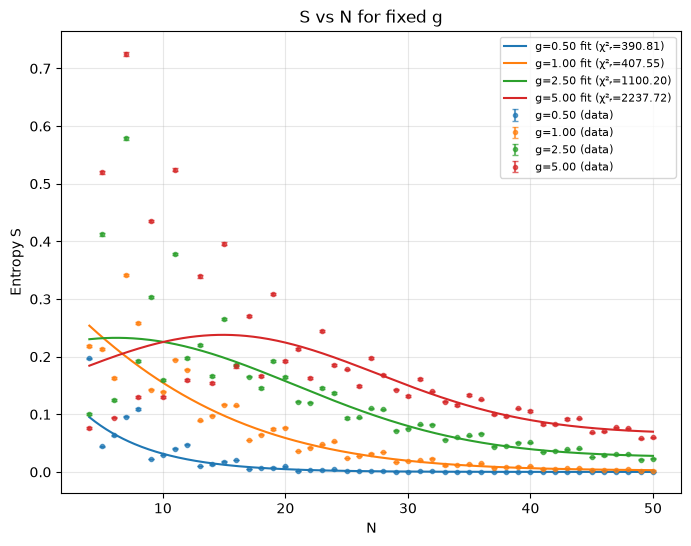

In [8]:
# S vs g for a few N values, with polynomial fits overlaid
# plot_S_vs_g(N_values, g_values[:], entropy[:,:], error[:,:], N_list=[10,20,30,40,50], degree=6)
# plt.show()

# S vs N for a few g values, with Gaussian fits overlaid
plot_S_vs_N(N_values, g_values, entropy, error, g_list=[0.5, 1, 2.5, 5])
plt.show()

# Full 3D surface
# plot_surface(N_values[:16], g_values[:], entropy[:16,:],cmap='viridis',elev=30,azim=-40)
# plt.savefig("S2(N,g)_surface(N<18).png",format = 'png', dpi=600)
# plt.show()